In [ ]:
!pip -q install openpyxl statsmodels joblib

# =========================
# Import libraries + settings
# =========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Split
TRAIN_END = 2016
TEST_START = 2017
TEST_END = 2022

LOOKBACK = 5

# Feature enhanced
USE_ENHANCED = True


Load dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

DATA_PATH = "/content/drive/MyDrive/DSGP/Final_MasterDataset.csv"
df = pd.read_csv(DATA_PATH)

print("Loaded:", DATA_PATH)
print(df.shape)
df.head()


Mounted at /content/drive
Loaded: /content/drive/MyDrive/DSGP/Final_MasterDataset.csv
(155, 19)


,Country,Year,D_Expenditure_GDP,Conflict_Intensity,Health_Expenditure_(% of GDP),Education_Expenditure_(% of GDP),Environmental_impact(CO2e/capita),"PM2.5 air pollution, mean annual exposure (micrograms per cubic meter)\n",Refugees,Asylum Seekers,Total number of deaths,Population,GDP_Growth_Annual,GDP_PerCapita_Growth_Annual,GDP_Current_USDollars,Inflation_Annual,Unemployment_Total_of_TLF,Unemployment_Male_of_TMF,Unemployment_Female_of_TFF
0,USA,1994,4.215265,NaN,NaN,NaN,19.83,13.78,364,0,0,263126000,4.029023,2.761109,7.290000e+12,2.607442,6.119,6.174,6.052
1,USA,1995,3.860246,NaN,NaN,NaN,19.79,13.67,243,0,0,266278000,2.684431,1.468929,7.640000e+12,2.805420,5.650,5.633,5.671
2,USA,1996,3.554982,NaN,NaN,NaN,20.14,13.52,141,0,0,269394000,3.772773,2.572464,8.070000e+12,2.931204,5.451,5.435,5.470
3,USA,1997,3.554982,NaN,NaN,NaN,20.90,13.34,75,0,0,272657000,4.447128,3.197166,8.580000e+12,2.337690,5.000,4.938,5.075
4,USA,1998,3.201558,NaN,NaN,NaN,20.83,13.13,50,0,0,275854000,4.483133,3.272230,9.060000e+12,1.552279,4.511,4.419,4.623


Basic cleaning

In [ ]:
df.columns = df.columns.str.strip()
df["Year"] = df["Year"].astype(int)

df = df.sort_values(["Country", "Year"]).reset_index(drop=True)

all_nan_cols = [c for c in df.columns if df[c].isna().all()]
print("Dropping fully-empty cols:", all_nan_cols)
df = df.drop(columns=all_nan_cols, errors="ignore")

missing = df.isna().mean().sort_values(ascending=False)
print(missing.head(10))


Dropping fully-empty cols: ['Conflict_Intensity']
Health_Expenditure_(% of GDP)                                             0.251613
Education_Expenditure_(% of GDP)                                          0.193548
Environmental_impact(CO2e/capita)                                         0.032258
Country                                                                   0.000000
Year                                                                      0.000000
D_Expenditure_GDP                                                         0.000000
PM2.5 air pollution, mean annual exposure (micrograms per cubic meter)    0.000000
Refugees                                                                  0.000000
Asylum Seekers                                                            0.000000
Total number of deaths                                                    0.000000
dtype: float64


Select targets + inputs

In [ ]:
TARGETS = ["Health_Expenditure_(% of GDP)", "Education_Expenditure_(% of GDP)"]

CORE_FEATURES = ["Year", "D_Expenditure_GDP"]
ENHANCED_FEATURES = ["GDP_Growth_Annual", "Inflation_Annual", "Unemployment_Total_of_TLF", "Population"]

FEATURES = CORE_FEATURES + (ENHANCED_FEATURES if USE_ENHANCED else [])

keep_cols = ["Country"] + FEATURES + TARGETS
df = df[keep_cols].copy()

print("Using FEATURES:", FEATURES)
print("Using TARGETS:", TARGETS)
df.head()


Using FEATURES: ['Year', 'D_Expenditure_GDP', 'GDP_Growth_Annual', 'Inflation_Annual', 'Unemployment_Total_of_TLF', 'Population']
Using TARGETS: ['Health_Expenditure_(% of GDP)', 'Education_Expenditure_(% of GDP)']


,Country,Year,D_Expenditure_GDP,GDP_Growth_Annual,Inflation_Annual,Unemployment_Total_of_TLF,Population,Health_Expenditure_(% of GDP),Education_Expenditure_(% of GDP)
0,CHN,1994,1.693480,13.072710,24.256990,2.90,1191835000,NaN,1.98571
1,CHN,1995,1.686234,11.032810,16.791230,3.00,1204855000,NaN,1.84192
2,CHN,1996,1.652727,9.976200,8.313160,3.12,1217550000,NaN,1.85339
3,CHN,1997,1.632651,9.287647,2.786465,3.23,1230075000,NaN,NaN
4,CHN,1998,1.655081,7.920792,-0.773190,3.24,1241935000,NaN,1.84433


Handle missing values (features only)

In [ ]:
num_feature_cols = FEATURES.copy()

def fill_features(group: pd.DataFrame) -> pd.DataFrame:
    group = group.sort_values("Year").copy()
    group[num_feature_cols] = group[num_feature_cols].interpolate(method="linear", limit_direction="both")
    group[num_feature_cols] = group[num_feature_cols].ffill().bfill()
    return group

df = df.groupby("Country", group_keys=False).apply(fill_features)
print("After feature imputation, shape:", df.shape)


After feature imputation, shape: (155, 9)


/tmp/ipython-input-3441175292.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby("Country", group_keys=False).apply(fill_features)


Train/Test split (DON’T drop targets here)

In [ ]:
train_df = df[df["Year"] <= TRAIN_END].copy()
test_df  = df[(df["Year"] >= TEST_START) & (df["Year"] <= TEST_END)].copy()

print("Train years:", train_df["Year"].min(), "-", train_df["Year"].max(), " | rows:", len(train_df))
print("Test years :", test_df["Year"].min(), "-", test_df["Year"].max(),  " | rows:", len(test_df))


Train years: 1994 - 2016  | rows: 115
Test years : 2017 - 2022  | rows: 30


One-hot encode Country

In [ ]:
df_encoded = pd.get_dummies(df, columns=["Country"], drop_first=False)
country_cols = [c for c in df_encoded.columns if c.startswith("Country_")]
df_encoded[country_cols] = df_encoded[country_cols].astype(int)

print("Country one-hot cols:", country_cols)
df_encoded.head()


Country one-hot cols: ['Country_CHN', 'Country_FRA', 'Country_GBR', 'Country_RUS', 'Country_USA']


,Year,D_Expenditure_GDP,GDP_Growth_Annual,Inflation_Annual,Unemployment_Total_of_TLF,Population,Health_Expenditure_(% of GDP),Education_Expenditure_(% of GDP),Country_CHN,Country_FRA,Country_GBR,Country_RUS,Country_USA
0,1994,1.693480,13.072710,24.256990,2.90,1191835000,NaN,1.98571,1,0,0,0,0
1,1995,1.686234,11.032810,16.791230,3.00,1204855000,NaN,1.84192,1,0,0,0,0
2,1996,1.652727,9.976200,8.313160,3.12,1217550000,NaN,1.85339,1,0,0,0,0
3,1997,1.632651,9.287647,2.786465,3.23,1230075000,NaN,NaN,1,0,0,0,0
4,1998,1.655081,7.920792,-0.773190,3.24,1241935000,NaN,1.84433,1,0,0,0,0


Scaling


In [ ]:
# Keep raw year for consecutive-year logic
df_encoded["Year_raw"] = df_encoded["Year"]

# Split for fitting scalers
train_enc = df_encoded[df_encoded["Year_raw"] <= TRAIN_END].copy()
test_enc  = df_encoded[df_encoded["Year_raw"] <= TEST_END].copy()  # keep history

# Separate scalers
x_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()

x_cols = FEATURES                 # inputs only (includes Year)
y_cols = TARGETS                  # outputs only

# Fit scalers on TRAIN only
x_scaler.fit(train_enc[x_cols])
y_scaler.fit(train_enc[y_cols].dropna())  # fit only on available target values

def apply_scaling(frame):
    frame = frame.copy()
    frame[x_cols] = x_scaler.transform(frame[x_cols])

    # Scale targets only where present (avoid NaN transform crash)
    mask = frame[y_cols].notna().all(axis=1)
    frame.loc[mask, y_cols] = y_scaler.transform(frame.loc[mask, y_cols])
    return frame

train_scaled = apply_scaling(train_enc)
test_scaled  = apply_scaling(test_enc)

print("Scaled train shape:", train_scaled.shape)
print("Scaled test/history shape:", test_scaled.shape)


Scaled train shape: (115, 14)
Scaled test/history shape: (145, 14)


Build sequences

In [ ]:
# Model input features (recommended: do NOT include past targets first)
step_feature_cols = FEATURES + country_cols

def build_sequences(df_scaled, lookback, feature_cols, target_cols, target_year_min, target_year_max):
    X_list, y_list, meta_list = [], [], []

    # Group each country by its one-hot combination
    for _, g in df_scaled.groupby(country_cols, sort=False):
        g = g.sort_values("Year_raw").reset_index(drop=True)

        years_raw = g["Year_raw"].values
        X_vals = g[feature_cols].values
        y_vals = g[target_cols].values  # targets scaled by y_scaler where available

        for i in range(lookback, len(g)):
            y_year = years_raw[i]
            if not (target_year_min <= y_year <= target_year_max):
                continue

            # consecutive years check using Year_raw
            window_years = years_raw[i-lookback:i+1]
            if np.any(np.diff(window_years) != 1):
                continue

            # require y at time t to exist (not NaN)
            if np.any(np.isnan(y_vals[i])):
                continue

            X_seq = X_vals[i-lookback:i]   # past lookback timesteps
            y_t   = y_vals[i]              # scaled targets at year t

            X_list.append(X_seq)
            y_list.append(y_t)
            meta_list.append(y_year)

    return np.array(X_list), np.array(y_list), np.array(meta_list)

# Train sequences (targets in train years)
X_train, y_train, y_train_years = build_sequences(
    df_scaled=train_scaled,
    lookback=LOOKBACK,
    feature_cols=step_feature_cols,
    target_cols=TARGETS,
    target_year_min=int(train_scaled["Year_raw"].min()) + LOOKBACK,
    target_year_max=TRAIN_END
)

# Test sequences (targets 2017–2022)
X_test, y_test, y_test_years = build_sequences(
    df_scaled=test_scaled,
    lookback=LOOKBACK,
    feature_cols=step_feature_cols,
    target_cols=TARGETS,
    target_year_min=TEST_START,
    target_year_max=TEST_END
)

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_test :", X_test.shape,  "y_test :", y_test.shape)
print("Train sequences:", len(X_train))
print("Test sequences :", len(X_test))
print("Test target years covered:", np.unique(y_test_years))


X_train: (79, 5, 11) y_train: (79, 2)
X_test : (30, 5, 11) y_test : (30, 2)
Train sequences: 79
Test sequences : 30
Test target years covered: [2017 2018 2019 2020 2021 2022]


Build model

In [ ]:
if X_train.shape[0] == 0:
    raise ValueError("No train sequences. Reduce LOOKBACK or check data gaps/targets.")

n_features = X_train.shape[-1]

model = models.Sequential([
    layers.Input(shape=(LOOKBACK, n_features)),
    layers.LSTM(64, return_sequences=True),
    layers.Dropout(0.2),
    layers.LSTM(32),
    layers.Dropout(0.2),
    layers.Dense(32, activation="relu"),
    layers.Dense(2, activation="linear")
])

model.compile(optimizer="adam", loss="mse")
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 5, 64)          │        19,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 5, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,994 (128.88 KB)

 Trainable params: 32,994 (128.88 KB)

 Non-trainable params: 0 (0.00 B)

Train model

Epoch 1/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 8s 636ms/step - loss: 0.3348 - val_loss: 0.2646
Epoch 2/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 135ms/step - loss: 0.2715 - val_loss: 0.2052
Epoch 3/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 128ms/step - loss: 0.2139 - val_loss: 0.1444
Epoch 4/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 0.1622 - val_loss: 0.0849
Epoch 5/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - loss: 0.1055 - val_loss: 0.0486
Epoch 6/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - loss: 0.0705 - val_loss: 0.0483
Epoch 7/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step - loss: 0.0540 - val_loss: 0.0399
Epoch 8/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - loss: 0.0383 - val_loss: 0.0219
Epoch 9/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - loss: 0.0222 - val_loss: 0.0163
Epoch 10/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 0.0139 - val_loss: 0.0197
Epoch 11/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.0142 - val_loss: 0.0235
Epoch 12/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - loss: 0.0149 - v

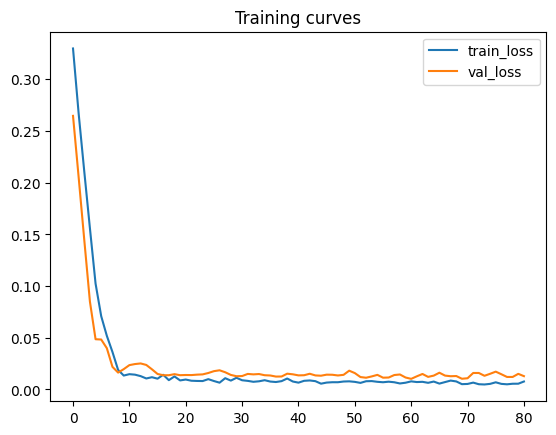

In [ ]:
# Time-based validation: last part of train years as validation
val_mask = (y_train_years >= 2014)  # you can adjust e.g. 2013/2015

X_tr, y_tr = X_train[~val_mask], y_train[~val_mask]
X_val, y_val = X_train[val_mask], y_train[val_mask]

cb_early = callbacks.EarlyStopping(monitor="val_loss", patience=20, restore_best_weights=True)

history = model.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=300,
    batch_size=16,
    callbacks=[cb_early],
    verbose=1
)

plt.figure()
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.legend()
plt.title("Training curves")
plt.show()


Evaluate (with empty-test guard)

X_test shape: (30, 5, 11)
Health: MAE=0.6365 | RMSE=0.8894 | R2=0.9569
Education: MAE=0.4899 | RMSE=0.6398 | R2=0.0722


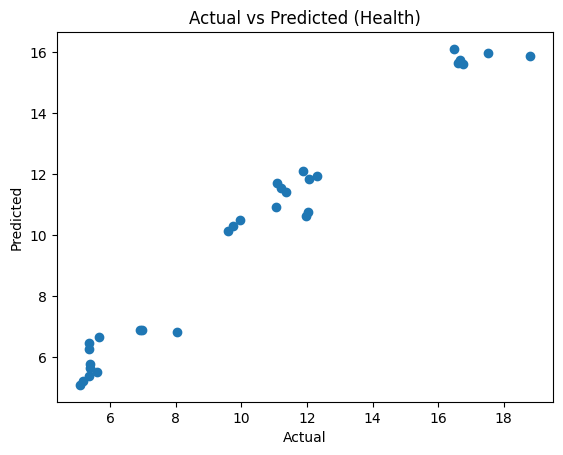

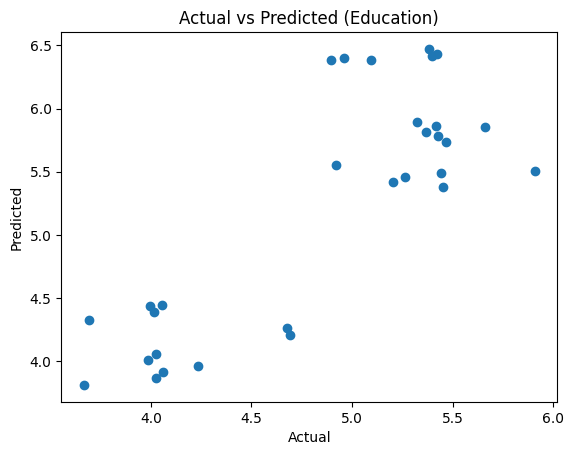

,Target,MAE,RMSE,R2
0,Health,0.636464,0.889374,0.956940
1,Education,0.489926,0.639793,0.072187


In [ ]:
print("X_test shape:", X_test.shape)

if X_test.shape[0] == 0:
    raise ValueError("X_test has 0 sequences. Reduce LOOKBACK or relax consecutive-year check.")

y_pred_scaled = model.predict(X_test, verbose=0)

y_true = y_scaler.inverse_transform(y_test.reshape(-1, 2))
y_pred = y_scaler.inverse_transform(y_pred_scaled.reshape(-1, 2))

def rmse(a, b):
    return np.sqrt(mean_squared_error(a, b))

labels = ["Health", "Education"]
for j, name in enumerate(labels):
    mae  = mean_absolute_error(y_true[:, j], y_pred[:, j])
    r    = rmse(y_true[:, j], y_pred[:, j])
    r2   = r2_score(y_true[:, j], y_pred[:, j])
    print(f"{name}: MAE={mae:.4f} | RMSE={r:.4f} | R2={r2:.4f}")

for j, name in enumerate(labels):
    plt.figure()
    plt.scatter(y_true[:, j], y_pred[:, j])
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title(f"Actual vs Predicted ({name})")
    plt.show()

metrics_rows = []
for j, name in enumerate(["Health", "Education"]):
    mae = mean_absolute_error(y_true[:, j], y_pred[:, j])
    rmse_val = np.sqrt(mean_squared_error(y_true[:, j], y_pred[:, j]))
    r2 = r2_score(y_true[:, j], y_pred[:, j])
    metrics_rows.append([name, mae, rmse_val, r2])

metrics_df = pd.DataFrame(metrics_rows, columns=["Target", "MAE", "RMSE", "R2"])
metrics_df


Save model + scalers

In [ ]:
model.save("health_edu_lstm.keras")
joblib.dump(x_scaler, "x_scaler.joblib")
joblib.dump(y_scaler, "y_scaler.joblib")

print("Saved: health_edu_lstm.keras, x_scaler.joblib, y_scaler.joblib")


Saved: health_edu_lstm.keras, x_scaler.joblib, y_scaler.joblib
